# 🏏 IPL Match Score Prediction using Linear Regression
**Bootcamp on Artificial Intelligence - NIELIT Delhi**

### Objective:
In this experiment, we implement **Supervised Machine Learning (Linear Regression)** on the IPL Matches Dataset (2008–2026):
1. Load and clean IPL match records (`IPL_Matches_Data_2008_2026.csv`).
2. Perform **Exploratory Data Analysis (EDA)** and compute correlation between match variables.
3. Build **Simple Linear Regression** ($y = mx + c$) to predict 2nd Innings Score based on 1st Innings Score.
4. Build **Multiple Linear Regression** ($y = m_1 x_1 + m_2 x_2 + m_3 x_3 + c$) incorporating wickets lost.
5. Evaluate both models using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.
6. Visualize the regression line, Actual vs. Predicted scatter, and residual distributions.
7. Predict outcomes for live match scenarios.

In [1]:
# 1. Environment & Library Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Environment ready!")
print("NumPy:       ", np.__version__)
print("pandas:      ", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy:        2.5.3
pandas:       3.0.6
scikit-learn: 1.9.1


In [2]:
# 2. Load Dataset
df = pd.read_csv("IPL_Matches_Data_2008_2026.csv")
print(f"Total Matches Loaded: {df.shape[0]} | Total Features: {df.shape[1]}")

# Display key match details
key_cols = ["date", "team1", "team2", "team1_runs", "team1_wickets", "team2_runs", "team2_wickets", "winner"]
df[key_cols].head()

Total Matches Loaded: 1243 | Total Features: 31


,date,team1,team2,team1_runs,team1_wickets,team2_runs,team2_wickets,winner
0,18-04-2008,Royal Challengers Bangalore,Kolkata Knight Riders,82,10,222,3,Kolkata Knight Riders
1,19-04-2008,Kings XI Punjab,Chennai Super Kings,207,4,240,5,Chennai Super Kings
2,19-04-2008,Delhi Daredevils,Rajasthan Royals,132,1,129,8,Delhi Daredevils
3,20-04-2008,Kolkata Knight Riders,Deccan Chargers,112,5,110,10,Kolkata Knight Riders
4,20-04-2008,Mumbai Indians,Royal Challengers Bangalore,165,7,166,5,Royal Challengers Bangalore


In [3]:
# 3. Data Cleaning & Correlation Analysis
# Filter completed matches with valid scores
df_clean = df[(df["team1_runs"] > 30) & (df["team2_runs"] > 30)].copy()
print(f"Valid matches for analysis: {len(df_clean)}")

# Correlation between match features
corr = df_clean[["team1_runs", "team1_wickets", "team2_runs", "team2_wickets"]].corr()
print("\n--- Correlation Matrix ---")
display(corr.round(3))

print(f"Linear correlation between 1st & 2nd Innings Runs: r = {corr.loc['team1_runs', 'team2_runs']:.3f}")

Valid matches for analysis: 1235

--- Correlation Matrix ---


,team1_runs,team1_wickets,team2_runs,team2_wickets
team1_runs,1.000,-0.285,0.666,0.171
team1_wickets,-0.285,1.000,-0.071,-0.225
team2_runs,0.666,-0.071,1.000,-0.211
team2_wickets,0.171,-0.225,-0.211,1.000


Linear correlation between 1st & 2nd Innings Runs: r = 0.666


In [4]:
# 4. Simple Linear Regression (1 Feature: team1_runs)
X_simple = df_clean[["team1_runs"]]
y = df_clean["team2_runs"]

# Train/Test Split (80% Train, 20% Test)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

# Train Model
simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train)

m_simple = simple_lr.coef_[0]
c_simple = simple_lr.intercept_

print(f"Fitted Line Equation: Team2_Runs = ({m_simple:.3f} * Team1_Runs) + {c_simple:.2f}")

# Evaluation
y_pred_s = simple_lr.predict(X_test_s)
r2_s = r2_score(y_test, y_pred_s)
mae_s = mean_absolute_error(y_test, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))

print(f"\nSimple Linear Regression Evaluation:")
print(f" - R² Score : {r2_s:.4f} ({r2_s * 100:.2f}% variance explained)")
print(f" - MAE      : {mae_s:.2f} runs")
print(f" - RMSE     : {rmse_s:.2f} runs")

Fitted Line Equation: Team2_Runs = (0.632 * Team1_Runs) + 52.92

Simple Linear Regression Evaluation:
 - R² Score : 0.4010 (40.10% variance explained)
 - MAE      : 16.74 runs
 - RMSE     : 24.53 runs


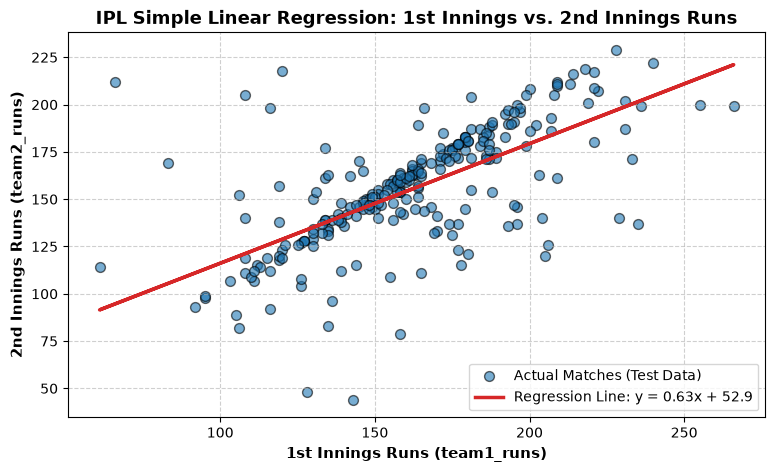

In [5]:
# 5. Visualize Simple Linear Regression Line
plt.figure(figsize=(9, 5))
plt.scatter(X_test_s["team1_runs"], y_test, color="#1f77b4", alpha=0.6, edgecolors="k", s=50, label="Actual Matches (Test Data)")
plt.plot(X_test_s["team1_runs"], y_pred_s, color="#d62728", linewidth=2.5, label=f"Regression Line: y = {m_simple:.2f}x + {c_simple:.1f}")
plt.xlabel("1st Innings Runs (team1_runs)", fontsize=11, fontweight="bold")
plt.ylabel("2nd Innings Runs (team2_runs)", fontsize=11, fontweight="bold")
plt.title("IPL Simple Linear Regression: 1st Innings vs. 2nd Innings Runs", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.show()

In [6]:
# 6. Multiple Linear Regression (Features: team1_runs, team1_wickets, team2_wickets)
features = ["team1_runs", "team1_wickets", "team2_wickets"]
X_multi = df_clean[features]

X_train_m, X_test_m, _, _ = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# Train Model
multi_lr = LinearRegression()
multi_lr.fit(X_train_m, y_train)

print("Multiple Regression Equation:")
print(f"Team2_Runs = {multi_lr.intercept_:.2f} + ({multi_lr.coef_[0]:.3f} * team1_runs) + ({multi_lr.coef_[1]:.3f} * team1_wickets) - ({abs(multi_lr.coef_[2]):.3f} * team2_wickets)")

# Evaluation
y_pred_m = multi_lr.predict(X_test_m)
r2_m = r2_score(y_test, y_pred_m)
mae_m = mean_absolute_error(y_test, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_m))

print(f"\nMultiple Linear Regression Evaluation:")
print(f" - R² Score : {r2_m:.4f} ({r2_m * 100:.2f}% variance explained)")
print(f" - MAE      : {mae_m:.2f} runs")
print(f" - RMSE     : {rmse_m:.2f} runs")

Multiple Regression Equation:
Team2_Runs = 62.88 + (0.698 * team1_runs) + (0.812 * team1_wickets) - (4.327 * team2_wickets)

Multiple Linear Regression Evaluation:
 - R² Score : 0.4456 (44.56% variance explained)
 - MAE      : 15.99 runs
 - RMSE     : 23.60 runs


In [7]:
# 7. Model Comparison Table
comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Features": ["1 (team1_runs)", "3 (team1_runs, team1_wickets, team2_wickets)"],
    "R² Score": [f"{r2_s:.4f}", f"{r2_m:.4f}"],
    "MAE (Runs)": [f"{mae_s:.2f}", f"{mae_m:.2f}"],
    "RMSE (Runs)": [f"{rmse_s:.2f}", f"{rmse_m:.2f}"]
})
display(comparison)

,Model,Features,R² Score,MAE (Runs),RMSE (Runs)
0,Simple Linear Regression,1 (team1_runs),0.4010,16.74,24.53
1,Multiple Linear Regression,"3 (team1_runs, team1_wickets, team2_wickets)",0.4456,15.99,23.60


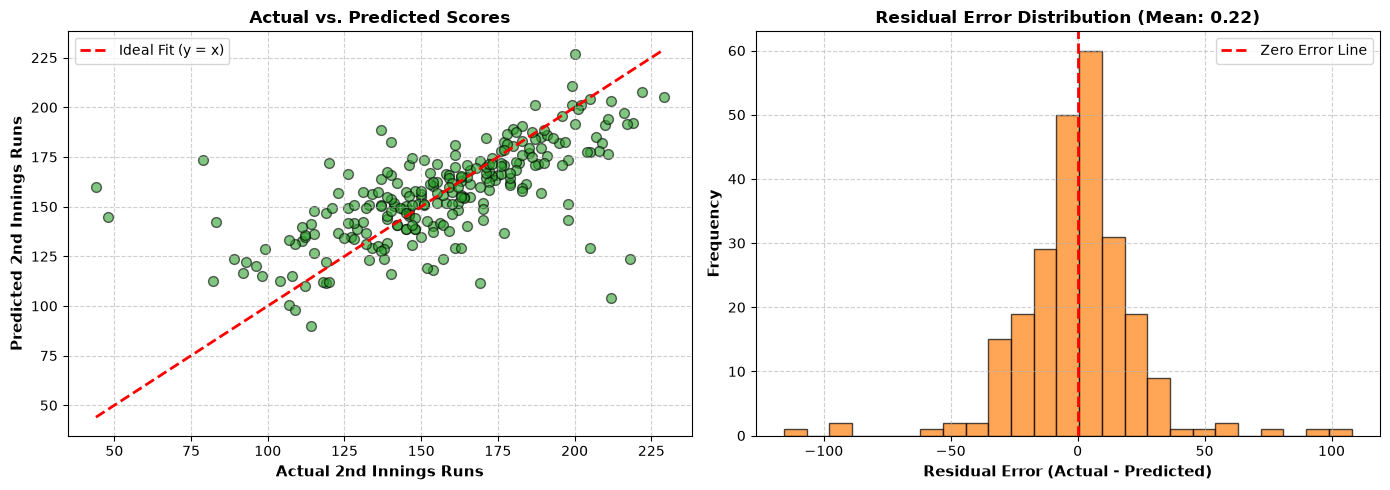

In [8]:
# 8. Actual vs. Predicted & Residual Distribution Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax1.scatter(y_test, y_pred_m, color="#2ca02c", alpha=0.6, edgecolors="k", s=50)
min_val = min(y_test.min(), y_pred_m.min())
max_val = max(y_test.max(), y_pred_m.max())
ax1.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Ideal Fit (y = x)")
ax1.set_xlabel("Actual 2nd Innings Runs", fontsize=11, fontweight="bold")
ax1.set_ylabel("Predicted 2nd Innings Runs", fontsize=11, fontweight="bold")
ax1.set_title("Actual vs. Predicted Scores", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Residual Error Distribution
residuals = y_test - y_pred_m
ax2.hist(residuals, bins=25, color="#ff7f0e", edgecolor="black", alpha=0.7)
ax2.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error Line")
ax2.set_xlabel("Residual Error (Actual - Predicted)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Frequency", fontsize=11, fontweight="bold")
ax2.set_title(f"Residual Error Distribution (Mean: {residuals.mean():.2f})", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# 9. Live Predictions on Custom Match Scenarios
match_scenarios = pd.DataFrame([
    {"Match": "CSK vs RCB (High Scoring Flat Pitch)", "team1_runs": 218, "team1_wickets": 3, "team2_wickets": 5},
    {"Match": "KKR vs SRH (Average Balanced Match)", "team1_runs": 165, "team1_wickets": 6, "team2_wickets": 7},
    {"Match": "DC vs LSG (Low Scoring Spin Track)", "team1_runs": 125, "team1_wickets": 9, "team2_wickets": 8}
])

predictions = multi_lr.predict(match_scenarios[["team1_runs", "team1_wickets", "team2_wickets"]])
match_scenarios["Predicted_Team2_Runs"] = np.round(predictions, 1)
display(match_scenarios)

,Match,team1_runs,team1_wickets,team2_wickets,Predicted_Team2_Runs
0,CSK vs RCB (High Scoring Flat Pitch),218,3,5,195.8
1,KKR vs SRH (Average Balanced Match),165,6,7,152.6
2,DC vs LSG (Low Scoring Spin Track),125,9,8,122.8
